<a href="https://colab.research.google.com/github/lankutse/Game-Genre-Recognition-Network/blob/main/Game%20Genre%20Recognition%20Model%200.5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
#@title importing necessary classes and modules
from tensorflow import keras
from keras.models import Sequential, Model
from keras import layers, losses
from keras.layers import Dense, Flatten, Reshape, Activation, LeakyReLU
from keras.optimizers import Adam
import pandas as pd
import matplotlib.pyplot as plt
import os
from sklearn.preprocessing import LabelEncoder
import numpy as np

#getting our dataset from kaggle
import kagglehub
path = kagglehub.dataset_download("gsimonx37/backloggd")
print("Path to dataset files:", path)


# Use the path from the kagglehub.dataset_download output
base_path = path # path is the variable from the previous cell
#loading the genres and the games
genres = pd.read_csv(f"{base_path}/genres.csv")
games = pd.read_csv(f"{base_path}/games.csv")



100%|██████████| 2.93G/2.93G [00:35<00:00, 88.0MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/gsimonx37/backloggd/versions/3


In [3]:
#@title configuring dataframe
genre_counts = (genres["genre"].value_counts().reset_index(name="count").rename(columns={"index": "genre"}))
#merging the genre data with the games data so we can get games per year by genre
genres_games = genres.merge(games,left_on="id",right_on="id",suffixes=('_genre', '_game'))
genres_games["date"] = pd.to_datetime(genres_games["date"],errors='coerce')
#dropping any missing dates
genres_games = genres_games.dropna(subset=["date"])
#extracting the year from our merged datasets
genres_games["year"] = genres_games["date"].dt.year
year_genre_counts = (genres_games.groupby(["year", "genre"]).size().reset_index(name="count"))
top_genres = genre_counts.head(10)["genre"].tolist()
filtered = year_genre_counts[year_genre_counts["genre"].isin(top_genres)]
pivoted = filtered.pivot(index="year", columns="genre", values="count").fillna(0)
genres_games.drop(['rating', 'reviews', 'plays', 'playing', 'backlogs', 'date', 'wishlists', 'description'], axis=1, inplace=True)
#narrowing our data down to only games from 2015 to 2025
games_filtered = genres_games[genres_games["year"] >= 2010].copy()
top_genre = (games_filtered["genre"].value_counts().head(10).index.tolist())
games_filtered = games_filtered[games_filtered["genre"].isin(top_genre)].copy()
#balancing our dataset by getting 100 games per genre per year, for 1,000 games per year and 10,000  games total
#the actual shape of the data is 10,135, because if some groups by genre/year had less than 100 games all of them were included.
sampled_games = games_filtered.groupby(['genre', 'year']).apply(lambda x: x.sample(n=100, replace=False, random_state = 24) if len(x) >= 100 else x).reset_index(drop=True)
# Get poster image filenames and IDs
poster_dir = os.path.join(path, "posters")
poster_files = os.listdir(poster_dir)
# Extract valid numeric poster IDs from filenames
poster_ids = [
    int(f.replace(".jpg", ""))
    for f in poster_files
    if f.endswith(".jpg") and f.replace(".jpg", "").isdigit()
]
available_ids = set(poster_ids)
# Encode genre strings into integer labels
le = LabelEncoder()
sampled_games["label"] = le.fit_transform(sampled_games["genre"])
print(sampled_games[["genre", "label"]].drop_duplicates())
genre_names = ["Adventure", "Arcade", "Indie", "Platform", "Puzzle", "RPG", "Shooter", "Simulator", "Strategy", "Visual Novel"]
#creating a multi-hot encoding vector so that each videogame/poster can correspond to multiple genres
#ex - if a game was in both the adventure (label 0) and shooter (label 6) genres, its vector would be:
# [1, 0, 0, 0, 0, 0, 1, 0, 0, 0]
def to_multihot(label_list, num_classes):
    vec = np.zeros(num_classes)
    vec[label_list] = 1
    return vec
#keeping only games/genres with matching poster id's (not all of the games in our dataset had posters)
genres_with_images = sampled_games[sampled_games["id"].isin(available_ids)].copy()
#get the genre(s) for each game into a list, put into the "labels" column
#ex - if a game has both is both action and shooter its label will be [0, 6]
genre_lists = genres_with_images.groupby("id")["label"].apply(list).reset_index()
genre_lists.rename(columns={"label": "labels"}, inplace=True)
#removing duplicate game entries because we have now combined their labels
metadata = genres_with_images.drop_duplicates("id")
#merging our data back together so that we have only 1 entry for each game that has a poster image
#and its corresponding genre labels
genres_with_images = metadata.merge(genre_lists, on="id")
genres_with_images.drop(['genre', 'label'], axis=1, inplace=True)
all_games = genres_with_images
print(f"There are {len(all_games)} games in our modified dataset")
all_games.head(5)

/tmp/ipykernel_4109/537828749.py:21: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sampled_games = games_filtered.groupby(['genre', 'year']).apply(lambda x: x.sample(n=100, replace=False, random_state = 24) if len(x) >= 100 else x).reset_index(drop=True)


              genre  label
0         Adventure      0
1537         Arcade      1
3038          Indie      2
4578       Platform      3
6083         Puzzle      4
7585            RPG      5
9115        Shooter      6
10618     Simulator      7
12125      Strategy      8
13629  Visual Novel      9
There are 13101 games in our modified dataset


,id,name,year,labels
0,1051213,Sam & Max: The Devil's Playhouse - Episode 5: ...,2010,[0]
1,1051521,Crime Lab: Body of Evidence,2010,[0]
2,1050404,Zelda Mobile,2010,[0]
3,1051023,Moon,2010,[0]
4,1051935,Sly Cooper and the Thievius Raccoonus,2010,"[0, 3]"


In [4]:
#@title load_images function
from tensorflow.keras.utils import load_img, img_to_array
import numpy as np

IMG_SIZE = (224, 224)

'''
This is a definition for the function load_images, which:
1. loops through each game, gets its ID number and genre labels
2. converts the label list into a one hot encoding vector ([1, 6] -> [0, 1, 0, 0, 0, 0, 1, 0, 0, 0])
3. loads the image and resizes it to 224, 224
   converts the image to a numpy array and normalizes pixel values to [0, 1].
Parameters: data and directory of posters
Returns:
the array of images (x) withshape: [number of samples, 224, 224, 3])
the array of multi-hot vectors (y) (shape: [number of samples, genres])
'''
def load_images(df, poster_dir):
    x = []
    y = []

#1
    for _, row in df.iterrows():
        game_id = row["id"]
        label_list = row["labels"]
#2
        multi_hot_label = np.zeros(10)
        multi_hot_label[label_list] = 1
        image_path = os.path.join(poster_dir, f"{game_id}.jpg")

#3
        try:
            img = load_img(image_path, target_size=IMG_SIZE)
            img_array = img_to_array(img) / 255.0
            x.append(img_array)
            y.append(multi_hot_label)

        except Exception as e:
            print(f"Error loading {image_path}: {e}")

    return np.array(x), np.array(y)

In [5]:
#shuffles the all_games dataset
all_games = all_games.sample(frac=1, random_state=42).reset_index(drop=True)

In [6]:
#SET DATA SEGMENT SIZE
#setting the data segment size
#5 chunks of 2620 for this data
#CHUNKS:
#ONE -  0:2620
#TWO - 2620:5240
#THREE - 5240:7860
#FOUR - 7860:10480
#FIVE - 10480:13101
data_segment = all_games.iloc[10480:13101]

In [7]:
!pip install scikit-multilearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.4/89.4 kB 1.8 MB/s eta 0:00:00


In [8]:
from skmultilearn.model_selection import iterative_train_test_split
#using the load_images function to match images to games/genres
x, y = load_images(data_segment, poster_dir)

#converting to arrays
x_np = np.array(x)
y_np = np.array(y)

#splitting our data segment into training and testing
x_train, y_train, x_test, y_test = iterative_train_test_split(x_np, y_np, test_size=0.2)

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

#printing label distributions
train_props = pd.Series(np.mean(y_train, axis=0), index=genre_names)
test_props = pd.Series(np.mean(y_test, axis=0), index=genre_names)
print("Training set genre distribution (proportions):")
print(train_props.sort_values(ascending=True))

print("\nTesting set genre distribution (proportions):")
print(test_props.sort_values(ascending=True))


x_train shape: (2095, 224, 224, 3)
y_train shape: (2095, 10)
x_test shape: (526, 224, 224, 3)
y_test shape: (526, 10)
Training set genre distribution (proportions):
Arcade          0.095943
Puzzle          0.101671
Indie           0.102148
Simulator       0.105012
Shooter         0.106444
Adventure       0.108831
Platform        0.109785
Visual Novel    0.109785
Strategy        0.111695
RPG             0.113604
dtype: float64

Testing set genre distribution (proportions):
Arcade          0.095057
Puzzle          0.100760
Indie           0.102662
Simulator       0.104563
Shooter         0.106464
Adventure       0.108365
Platform        0.108365
Visual Novel    0.110266
Strategy        0.112167
RPG             0.114068
dtype: float64


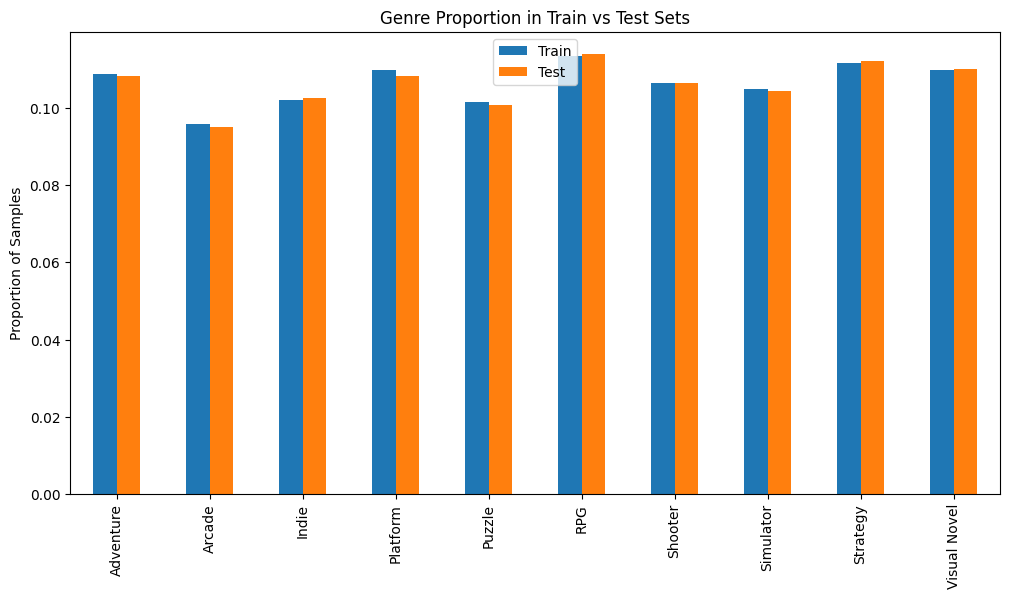

In [9]:
#EXPORT
import matplotlib.pyplot as plt
df = pd.DataFrame({
    'Train': train_props,
    'Test': test_props
})
df.plot(kind='bar', figsize=(12, 6), title="Genre Proportion in Train vs Test Sets")
plt.ylabel("Proportion of Samples")
plt.show()

In [10]:
import tensorflow as tf
from tensorflow import keras
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, GlobalAveragePooling2D, Dropout, Input
from keras.applications.efficientnet import EfficientNetB2
from keras.applications.densenet import DenseNet121
from keras.regularizers import l2

#loading the most updated model
model = keras.models.load_model("/content/drive/MyDrive/Colab Notebooks/green26_0-4.keras")

# #new model for 2026!
# base_model = DenseNet121(include_top=False, input_shape=(224,224,3))

# #freezing the model except for the last couple layers specified
# unfreeze = 20
# for layer in base_model.layers[:-unfreeze]:
#     layer.trainable = False

# #my model
# model = keras.models.Sequential([
#     base_model,
#     GlobalAveragePooling2D(),
#     Dense(128, activation='relu', kernel_regularizer=l2(0.001)),  #0.001 is the penalty factor/regularization strength
#     Dense(10, activation='sigmoid'),
# ])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       131,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,669,654 (29.26 MB)

 Trainable params: 499,658 (1.91 MB)

 Non-trainable params: 6,670,336 (25.45 MB)

 Optimizer params: 499,660 (1.91 MB)

In [11]:
from keras.optimizers import SGD, AdamW
#opt = tf.keras.optimizers.Adam(learning_rate=0.005)
####momentum basically leads to larger updates when the model is going in the right direction; helps avoid local minima
opt = optimizer = SGD(learning_rate=0.01, momentum = 0.9)
#opt = tf.keras.optimizers.AdamW(learning_rate=1e-3, weight_decay=1e-5)
model.compile(optimizer = opt, loss='binary_crossentropy', metrics=['accuracy', tf.keras.metrics.AUC(name='auc'), tf.keras.metrics.BinaryAccuracy(name='bin_acc')])
early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

#saving the weights/biases of the network after the best epoch
model_checkpoint = keras.callbacks.ModelCheckpoint(
    filepath='/content/drive/MyDrive/Colab Notebooks/26GGR-weights/0best-weights{epoch:02d}.weights.h5',
    save_weights_only=True, monitor='val_accuracy', mode='max', save_best_only=True)

In [12]:
training = model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.2, callbacks=[early_stop, model_checkpoint])
model.save("/content/drive/MyDrive/Colab Notebooks/green26_0-5.keras")
#printing training results
print("Final training accuracy:", training.history['accuracy'][-1])
print("Final training (categorical) loss:", training.history['loss'][-1])
print("Final validation accuracy:", training.history['val_accuracy'][-1])
print("Final validation (categorical) loss:", training.history['val_loss'][-1])

Epoch 1/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 407s 14s/step - accuracy: 0.2399 - auc: 0.6736 - bin_acc: 0.8946 - loss: 0.5029 - val_accuracy: 0.2625 - val_auc: 0.6747 - val_bin_acc: 0.8981 - val_loss: 0.4953
Epoch 2/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 375s 14s/step - accuracy: 0.2458 - auc: 0.6939 - bin_acc: 0.8953 - loss: 0.4952 - val_accuracy: 0.2434 - val_auc: 0.6839 - val_bin_acc: 0.8983 - val_loss: 0.4912
Epoch 3/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 377s 14s/step - accuracy: 0.2649 - auc: 0.7134 - bin_acc: 0.8961 - loss: 0.4874 - val_accuracy: 0.2387 - val_auc: 0.6869 - val_bin_acc: 0.8988 - val_loss: 0.4881
Epoch 4/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 382s 14s/step - accuracy: 0.2888 - auc: 0.7293 - bin_acc: 0.8964 - loss: 0.4801 - val_accuracy: 0.2482 - val_auc: 0.6771 - val_bin_acc: 0.8990 - val_loss: 0.4886
Epoch 5/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 380s 14s/step - accuracy: 0.3031 - auc: 0.7454 - bin_acc: 0.8962 - loss: 0.4743 - val_accuracy: 0.2530 - val_auc: 0.6850 - val_bin_acc: 0.8988 - val_loss: 0.4845
Final

In [ ]:
# model = keras.models.load_model("/content/drive/MyDrive/Colab Notebooks/green26_0-2.keras")

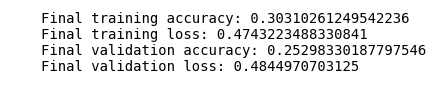

In [13]:
#EXPORT
training_info = (f"Final training accuracy: {training.history['accuracy'][-1]}\n"
                f"Final training loss: {training.history['loss'][-1]}\n"
                f"Final validation accuracy: {training.history['val_accuracy'][-1]}\n"
                f"Final validation loss: {training.history['val_loss'][-1]}\n")
fig, ax = plt.subplots(figsize=(4, 1))
ax.axis('off')  # hide axes
ax.text(0.1, 0.98, training_info, fontsize=10, va='top', family='monospace')
plt.show()

In [14]:
import numpy as np
from sklearn.metrics import accuracy_score, hamming_loss, f1_score, classification_report, confusion_matrix, multilabel_confusion_matrix
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

#assessing overall model performance
#setting threshold
threshold = 0.2

#predicting probablilities and binarizing output
y_pred_probs = model.predict(x_test)
y_pred = (y_pred_probs >= threshold).astype(int)

17/17 ━━━━━━━━━━━━━━━━━━━━ 94s 5s/step


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


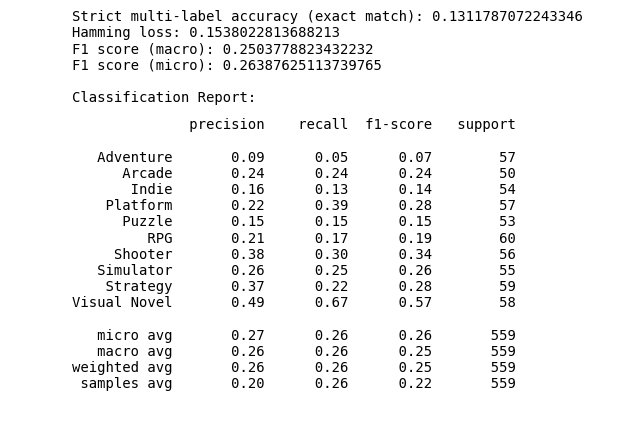

In [15]:
#EXPORT
#strict multi-label accuracy, model is only "correct" if it gets all the genres for a game right
strict_acc = accuracy_score(y_test, y_pred)

#hamming loss, evaluates miss classification by individual genre label
hamming = hamming_loss(y_test, y_pred)

# Macro and micro averaged F1 score
f1_macro = f1_score(y_test, y_pred, average='macro')
f1_micro = f1_score(y_test, y_pred, average='micro')

#generating the report
#high precision means few false positives, high recall means few false negatives
report = classification_report(y_test, y_pred, target_names = genre_names)

other_info = (f"Strict multi-label accuracy (exact match): {strict_acc}\n"
              f"Hamming loss: {hamming}\n"
              f"F1 score (macro): {f1_macro}\n"
              f"F1 score (micro): {f1_micro}\n"
              f"\nClassification Report:\n")

#saving it as a figure with text
fig, ax = plt.subplots(figsize=(8, 4))
ax.axis('off')  # hide axes
ax.text(0.1, 0.98, other_info, fontsize=10, family="monospace")
ax.text(0.1, 0.98, report, fontsize=10, va='top', family='monospace')
plt.show()


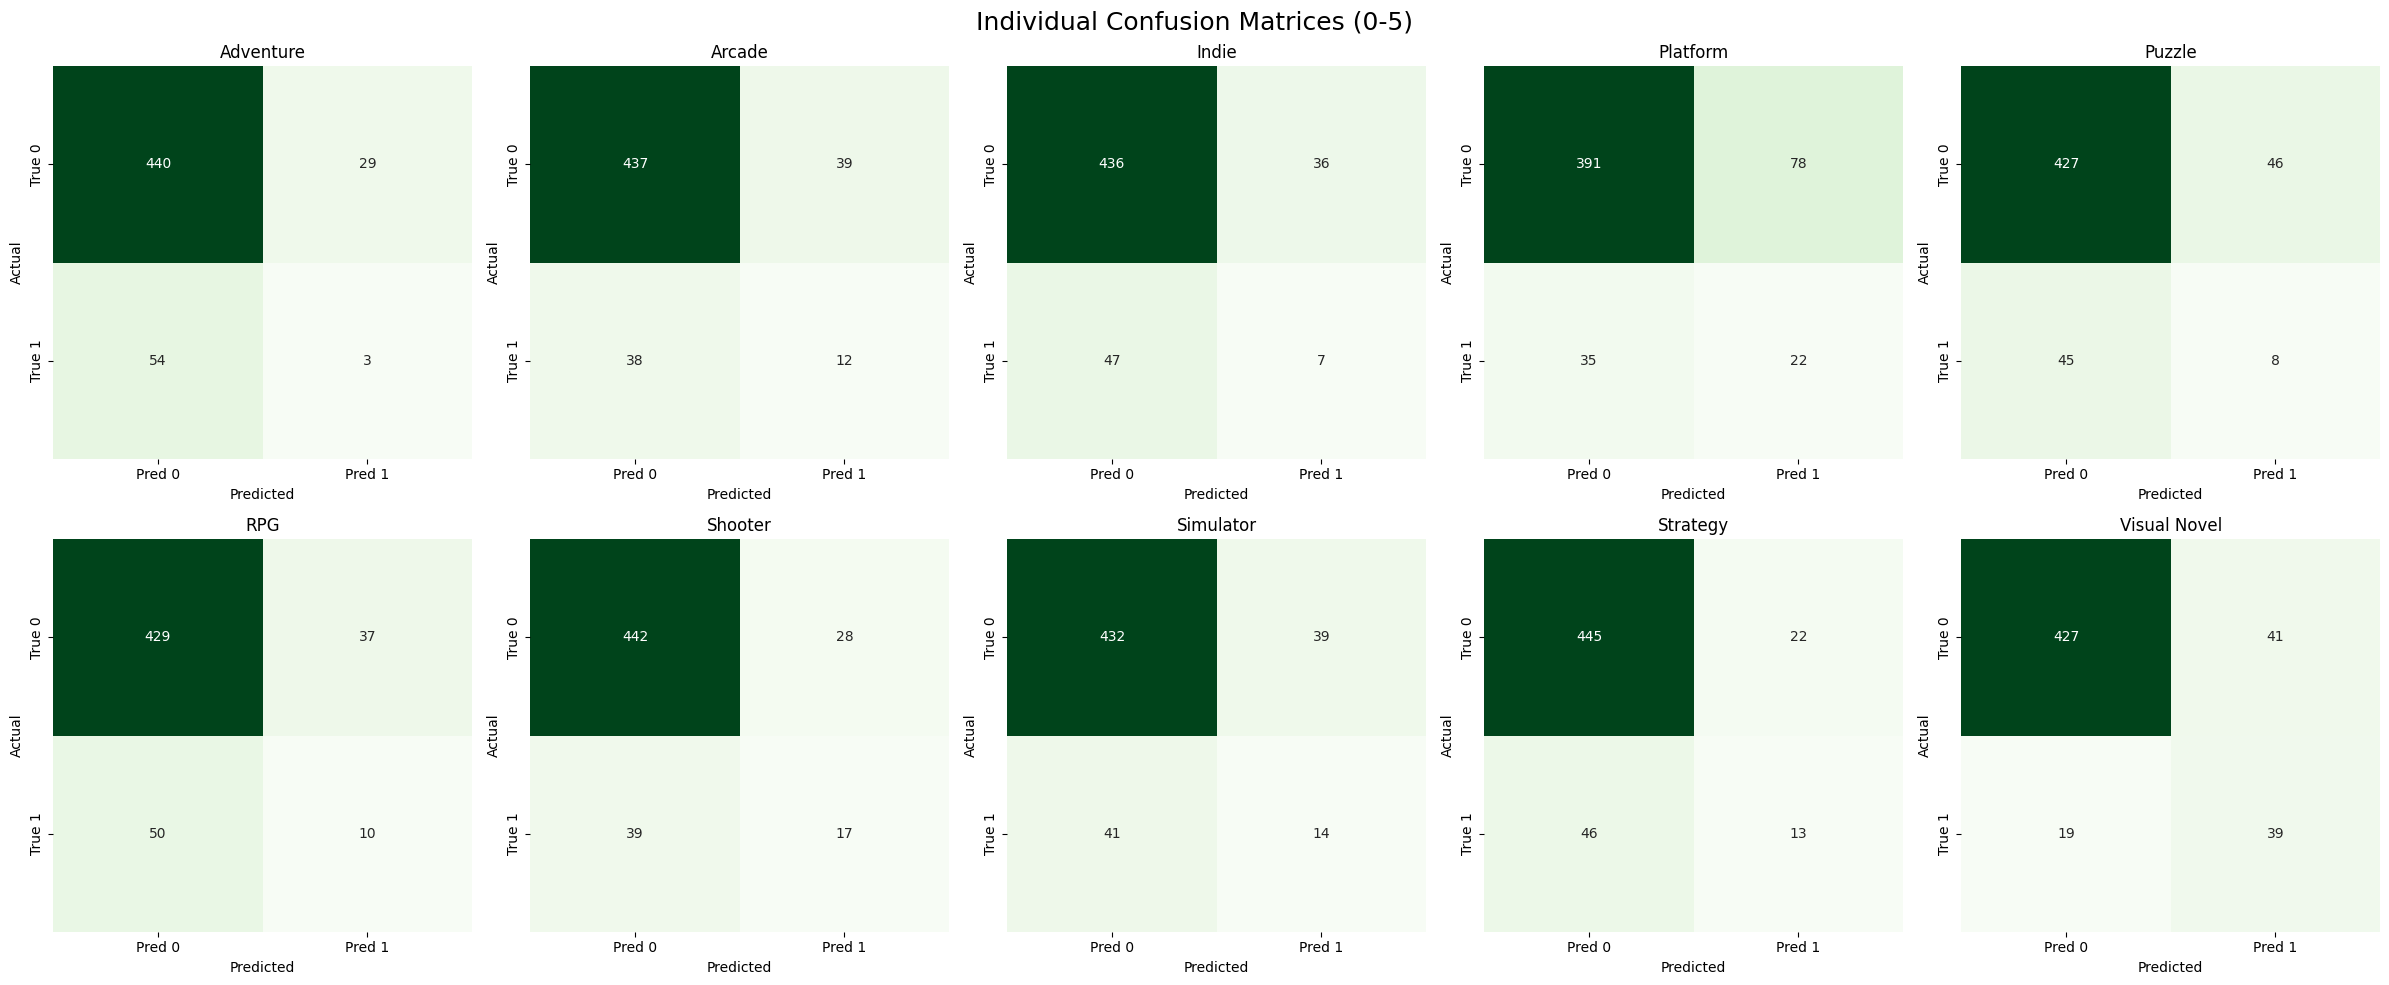

In [16]:
#EXPORT
#Plotting individual confusion matricies for each genre
mlcm = multilabel_confusion_matrix(y_test, y_pred)
class_labels = [f"Label {i}" for i in range(mlcm.shape[0])]


individual, axes = plt.subplots(nrows=2, ncols=5, figsize=(24, 10))
individual.suptitle("Individual Confusion Matrices (0-5)", fontsize=18)
for i, cm in enumerate(mlcm):
    row, col = divmod(i, 5)
    ax = axes[row, col]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', cbar=False,
                xticklabels=["Pred 0", "Pred 1"],
                yticklabels=["True 0", "True 1"],
                ax=ax)
    ax.set_title(f"{genre_names[i]}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

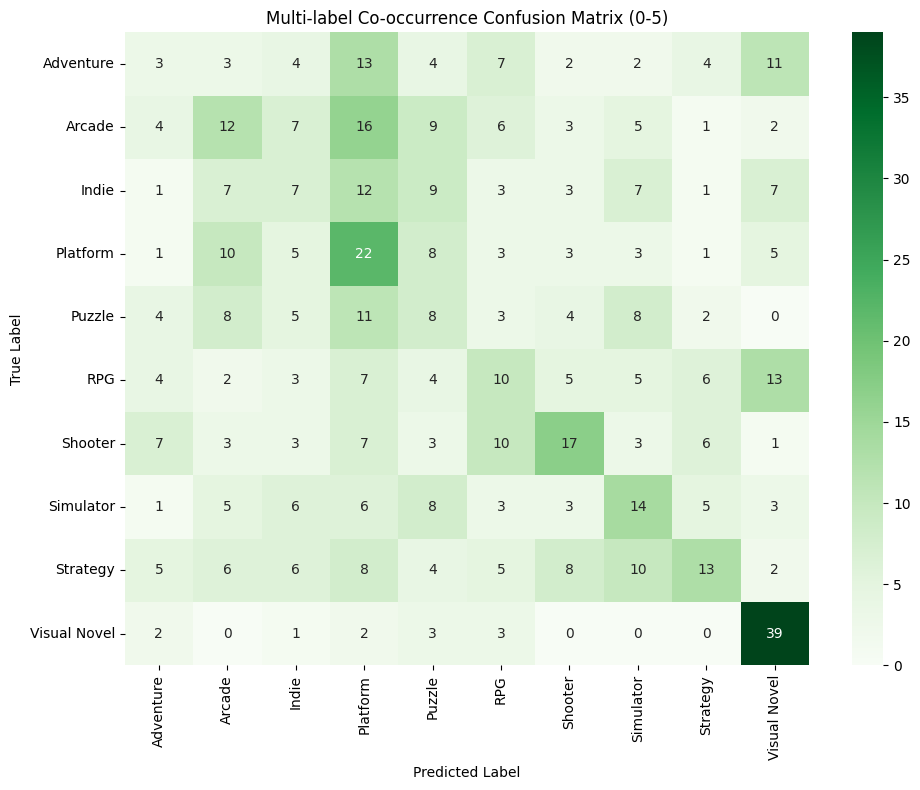

In [17]:
#EXPORT
#Generate a co-occurrence confusion matrix
#Each row is a true label vector, each column is a predicted label vector.
#This gives you a sense of how many labels were mispredicted together.

def multilabel_confusion_counts(y_true, y_pred):
    co_occurrence = np.zeros((y_true.shape[1], y_pred.shape[1]), dtype=int)
    for i in range(len(y_true)):
        true_indices = np.where(y_true[i] == 1)[0]
        pred_indices = np.where(y_pred[i] == 1)[0]
        for t in true_indices:
            for p in pred_indices:
                co_occurrence[t, p] += 1
    return co_occurrence

#Generate and plot the co-occurrence matrix
co_matrix = multilabel_confusion_counts(y_test, y_pred)

multilabel = plt.figure(figsize=(10, 8))
sns.heatmap(co_matrix, annot=True, fmt='d', cmap='Greens', xticklabels=genre_names, yticklabels=genre_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Multi-label Co-occurrence Confusion Matrix (0-5)")
plt.tight_layout()
plt.show()

In [18]:
import nbformat

input_path = "/content/drive/MyDrive/Colab Notebooks/Green Network.ipynb"
output_path = "/content/drive/MyDrive/Colab Notebooks/green26_0-5.ipnyb"

with open(input_path) as f:
    nb = nbformat.read(f, as_version=4)

# Filter: keep only cells that contain plotting code
figure_cells = [
    cell for cell in nb.cells
    if cell.cell_type == "code" and ("#EXPORT" in cell.source)
]

nb.cells = figure_cells

with open(output_path, 'w') as f:
    nbformat.write(nb, f)

In [19]:
!apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic
!jupyter nbconvert --to pdf "/content/drive/MyDrive/Colab Notebooks/green26_0-5.ipnyb"

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono
  fonts-texgyre fonts-urw-base35 libapache-pom-java libcommons-logging-java
  libcommons-parent-java libfontbox-java libgs9 libgs9-common libidn12
  libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern poppler-data preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  teckit tex-common tex-gyre texlive-base texlive-binaries texlive-latex-base
  texlive-latex-extra texlive-latex-recommended texlive-pictures tipa
  xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto fonts-freefont-otf | fonts-freefont-ttf libavalon-framework-java
  libcommons-logging-java-doc libexcalibur-logkit-java 